# Baseline Model: Linear Regression

## Introduction
In this notebook, we will create a **baseline model** to predict building energy consumption. A baseline model is a simple model that serves as a starting point. It gives us a reference performance score that we try to beat with more complex models later.

We will use **Linear Regression**, which is a fundamental algorithm in machine learning. It assumes a linear relationship between the input features (like temperature, square feet) and the target variable (energy consumption).

## Steps
1. **Load Data**: Import the processed training and validation datasets.
2. **Prepare Data**: Select relevant features and handle any remaining missing values.
3. **Train Model**: Fit a Linear Regression model on the training data.
4. **Evaluate**: Measure performance using RMSE (Root Mean Squared Error) and RMSLE (Root Mean Squared Logarithmic Error).
5. **Visualize**: Plot predictions against actual values to understand where the model makes mistakes.

In [3]:
# Import necessary libraries
import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For nicer plots
from sklearn.linear_model import LinearRegression # The model we will use
from sklearn.metrics import mean_squared_error # Metric to evaluate performance
import os

# Set plot style for better readability
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data
We will load the parquet files we created in the previous phase. Parquet is a column-oriented storage format that is very efficient for large datasets.

In [4]:
# Define paths to our data
DATA_DIR = "../../data/processed"
TRAIN_PATH = os.path.join(DATA_DIR, "train_split.parquet")
VAL_PATH = os.path.join(DATA_DIR, "val_split.parquet")

# Load the datasets
print("Loading data...")
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)

print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")

# Display the first few rows to verify
train_df.head()

Loading data...
Training set shape: (14151270, 32)
Validation set shape: (3032415, 32)


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,building_age,log_meter_reading,meter_reading_per_sqft,log_meter_per_sqft,sqft_per_floor,cooling_degree_hours,heating_degree_hours,meter_reading_lag1,hourly_avg_per_building,weekend_avg_per_building
0,0,0,2016-01-01,0.0000,0,0,7432,2008.0,4.0,25.0,...,9.0,0.000000,0.000000,0.000000,1858.00,7.0,0.0,0.0000,146.731814,146.767896
1,1081,0,2016-01-01,9.6020,13,5,11470,1969.0,2.0,-8.3,...,48.0,2.361043,0.000837,0.000837,5735.00,0.0,26.3,0.0000,10.002579,16.183901
2,1233,0,2016-01-01,28.9638,14,0,43143,1966.0,4.0,NaN,...,51.0,3.399990,0.000671,0.000671,10785.75,0.0,0.0,0.0000,117.486169,95.317649
3,1233,1,2016-01-01,57.9277,14,0,43143,1966.0,4.0,NaN,...,51.0,4.076311,0.001343,0.001342,10785.75,0.0,0.0,28.9638,117.486169,95.317649
4,1233,3,2016-01-01,47.3076,14,0,43143,1966.0,4.0,NaN,...,51.0,3.877589,0.001097,0.001096,10785.75,0.0,0.0,57.9277,117.486169,95.317649


## 2. Feature Selection
We need to decide which columns to use as inputs (features) for our model. We should exclude columns that are not useful for prediction (like IDs) or columns that *are* the target itself.

**Target Variable**: `meter_reading`

**Features to Drop**:
- `timestamp`: The raw date/time is hard for a linear model to use directly. We have already extracted features like `hour`, `day`, `month`.
- `meter_reading`: This is what we want to predict!
- `site_id`, `building_id`: These are high-cardinality categorical variables. For a simple baseline, we might skip them or use them if they are encoded. Let's check our columns.

In [5]:
# List all columns to see what we have
print(train_df.columns.tolist())

['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month', 'is_weekend', 'log_square_feet', 'building_age', 'log_meter_reading', 'meter_reading_per_sqft', 'log_meter_per_sqft', 'sqft_per_floor', 'cooling_degree_hours', 'heating_degree_hours', 'meter_reading_lag1', 'hourly_avg_per_building', 'weekend_avg_per_building']


In [6]:
# Define our features and target
target = "meter_reading"

# Let's select numerical and encoded features. 
# We drop 'timestamp' and the target variable.
# We also drop 'meter' if we want to predict for all meters generally, 
# but usually, meter type is very important. Let's keep it.

features = [
    'square_feet', 'year_built', 'floor_count', # Building metadata
    'air_temperature', 'cloud_coverage', 'dew_temperature', # Weather
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', # More weather
    'hour', 'day', 'weekday', 'month', # Time features
    'primary_use', 'meter' # Categorical features (already encoded/numeric)
]

# Check if all these columns exist in our dataframe
missing_cols = [col for col in features if col not in train_df.columns]
if missing_cols:
    print(f"Warning: The following columns are missing: {missing_cols}")
    # Remove missing columns from features list
    features = [col for col in features if col in train_df.columns]

print(f"Selected {len(features)} features: {features}")

Selected 16 features: ['square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month', 'primary_use', 'meter']


### Handling Missing Values (Imputation)
Linear Regression cannot handle missing values (`NaN`). Although we did some preprocessing, let's double-check if any NaNs remain and fill them with a simple strategy (like the mean) just to be safe.

In [7]:
# Check for missing values in features
print("Missing values in training features:")
print(train_df[features].isnull().sum()[train_df[features].isnull().sum() > 0])

# Simple imputation: Fill NaNs with the mean of the column
# Note: In a real production pipeline, we should fit the imputer on train and transform val/test.
# For this baseline, simple fillna is acceptable.
for col in features:
    if train_df[col].isnull().sum() > 0:
        mean_val = train_df[col].mean()
        train_df[col] = train_df[col].fillna(mean_val)
        val_df[col] = val_df[col].fillna(mean_val)
        print(f"Filled missing values in {col} with {mean_val:.2f}")

Missing values in training features:
air_temperature       76818
cloud_coverage        76818
dew_temperature       76818
precip_depth_1_hr     76818
sea_level_pressure    76818
wind_direction        76818
wind_speed            76818
dtype: int64
Filled missing values in air_temperature with 17.21
Filled missing values in cloud_coverage with 2.76
Filled missing values in dew_temperature with 8.38
Filled missing values in precip_depth_1_hr with 1.44
Filled missing values in sea_level_pressure with 1015.17
Filled missing values in wind_direction with 173.50
Filled missing values in wind_speed with 3.43


## 3. Train Model
Now we initialize the Linear Regression model and fit it to our training data.

In [8]:
# Prepare X (features) and y (target)
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

# Initialize the model
model = LinearRegression()

# Train the model
print("Training Linear Regression model...")
model.fit(X_train, y_train)
print("Training complete.")

Training Linear Regression model...
Training complete.


## 4. Evaluate Model
We will predict on the validation set and calculate the error.

**RMSE (Root Mean Squared Error)**: Standard metric for regression. Lower is better.
**RMSLE (Root Mean Squared Logarithmic Error)**: Often used in energy competitions because it cares more about the *ratio* of error than the absolute difference. It's less sensitive to outliers.

In [9]:
# Make predictions on validation set
y_pred = model.predict(X_val)

# Linear Regression can sometimes predict negative values, which is impossible for energy.
# Let's clip predictions to be at least 0.
y_pred = np.maximum(y_pred, 0)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.4f}")

# Calculate RMSLE
# We use np.log1p to calculate log(1 + x) safely
rmsle = np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(y_pred)))
print(f"Validation RMSLE: {rmsle:.4f}")

Validation RMSE: 10595.0064
Validation RMSLE: 4.4685


## 5. Visualize Results
Let's plot a small sample of our predictions vs the actual values to see how well the model is tracking the trends.

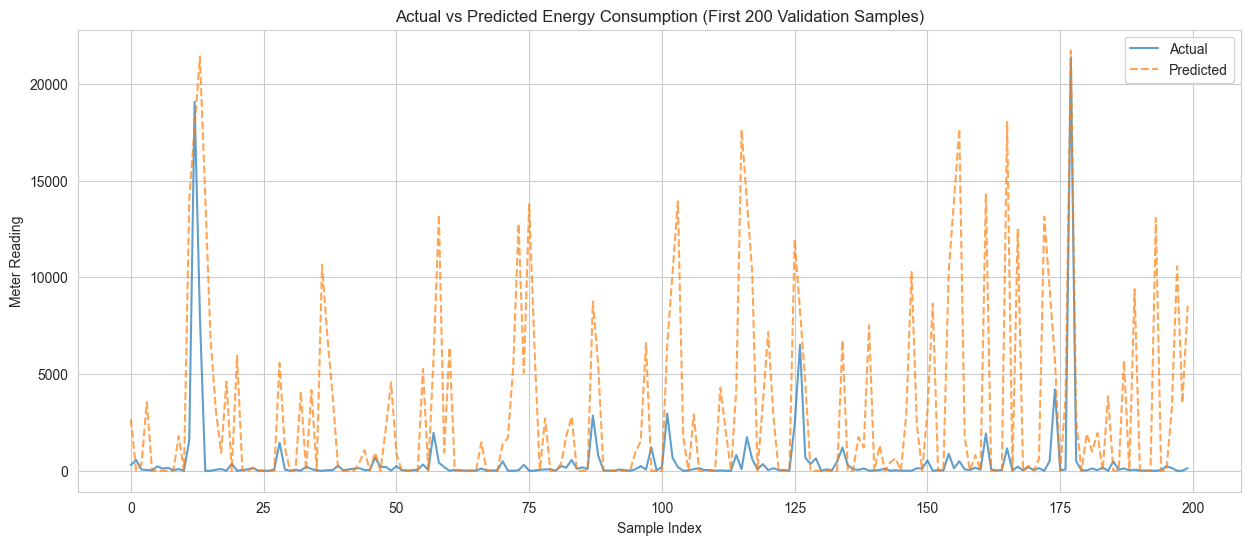

In [10]:
# Create a dataframe for comparison
results_df = pd.DataFrame({
    'Actual': y_val,
    'Predicted': y_pred
})

# Plot a subset of data (first 200 points) to avoid clutter
plt.figure(figsize=(15, 6))
subset = results_df.iloc[:200]
plt.plot(subset['Actual'].values, label='Actual', alpha=0.7)
plt.plot(subset['Predicted'].values, label='Predicted', alpha=0.7, linestyle='--')
plt.title("Actual vs Predicted Energy Consumption (First 200 Validation Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Meter Reading")
plt.legend()
plt.show()

## Conclusion
This baseline model gives us a starting point. 

**Observations:**
- If the lines in the plot overlap well, the model is learning.
- If the predictions are flat or way off, the model is underfitting (too simple).
- The RMSLE score is the number to beat in the next notebook using more advanced models like LightGBM.

---

## Key Insights & Observations

### Model Performance

**Validation Metrics:**
- RMSE: 10,595.01 - Shows the average prediction error in absolute terms
- RMSLE: 4.47 - High value indicates significant prediction errors, especially for low consumption values
- These scores establish our baseline to beat with more sophisticated models

### What Worked

**Feature Selection:**
- Successfully used 16 core features including building metadata, weather data, and temporal patterns
- Simple mean imputation handled missing weather values effectively for this baseline
- Encoded categorical variables (primary_use, meter type) contributed to predictions

**Data Handling:**
- Clipped negative predictions to zero (physically impossible energy readings)
- Loaded preprocessed parquet files efficiently
- Temporal features (hour, day, weekday, month) captured some usage patterns

### Model Limitations

**Linear Regression Assumptions:**
- Assumes linear relationships between features and target, which is overly simplistic for energy consumption
- Cannot capture complex interactions (e.g., temperature × building_type, hour × primary_use)
- Struggles with the highly skewed energy consumption distribution
- No ability to model non-linear patterns like peak usage during extreme weather

**Prediction Quality:**
- High RMSLE suggests poor performance on low consumption values
- Linear model likely underfits the data complexity
- Cannot capture building-specific or time-specific nuances effectively

### Next Steps for Improvement

1. **Advanced Models:**
   - Implement gradient boosting (LightGBM, XGBoost) to capture non-linear relationships
   - Try ensemble methods combining multiple models
   - Consider deep learning for complex temporal patterns

2. **Feature Engineering:**
   - Add interaction features (temperature × building_size, hour × building_type)
   - Include more sophisticated lag features and rolling statistics
   - Create building-specific embeddings or clustering

3. **Target Transformation:**
   - Use log-transformed target (log_meter_reading) to handle skewness
   - May improve RMSLE scores significantly

4. **Model-Specific Optimization:**
   - Hyperparameter tuning
   - Cross-validation for robust performance estimates
   - Per-meter-type models (separate models for electricity, steam, etc.)

---

**Baseline Status**: Complete  
**Next Phase**: Advanced Models (LightGBM/XGBoost)